# Import the essential libraries

In [1]:
 #!pip install rasterio

In [2]:
 #!pip install scikit-learn==0.24.2

In [3]:
#!pip install Pillow

In [4]:
#!pip install matplotlib

In [5]:
#!pip install seaborn

In [6]:
#!pip install scikit-learn

In [1]:
# Essential and common packages
import os
import glob
from PIL import Image
import shutil
# Read and visualize the raster data
import rasterio
from rasterio.plot import show

# Plots and bars
import matplotlib.pyplot as plt
import seaborn as sns

# Computation library
import numpy as np

# Tensorflow for building the resnet50 model
import tensorflow.python.keras as k
import tensorflow as tf
from tensorflow.keras.layers import Input, Add, Dense, Activation, ZeroPadding2D, BatchNormalization, Flatten, Conv2D, AveragePooling2D, MaxPooling2D, GlobalMaxPooling2D
from tensorflow.keras.initializers import random_uniform, glorot_uniform
from tensorflow.keras.models import Model, load_model

# Sklearn for confusion matrix
import itertools
#from sklearn.metrics import confusion_matrix, plot_confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# For visualization of plots without plt.show()
%matplotlib inline

In [2]:
tf.__version__

'2.19.0'

# Define the required variable

# Data preparation for the model

In [3]:
#datagen = tf.keras.preprocessing.image.ImageDataGenerator(validation_split=validation_split, rescale=rescale)
#dataset = tf.keras.preprocessing.image_dataset_from_directory(dataset_url, image_size=(img_height, img_width), batch_size=batch_size)

In [4]:

# Set image size
IMG_SIZE = (224, 224)  # ResNet50 default input size
BATCH_SIZE = 16

# Load datasets from folders
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    r"C:\Users\YapJack\Desktop\DeepEarthMY\train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'  
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    r"C:\Users\YapJack\Desktop\DeepEarthMY\val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    r"C:\Users\YapJack\Desktop\DeepEarthMY\test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

Found 3222 files belonging to 2 classes.
Found 701 files belonging to 2 classes.
Found 711 files belonging to 2 classes.


In [5]:
for images, labels in test_dataset.take(1):  # Take one batch
    print(labels.numpy())  # Print label values (0 or 1)
print(test_dataset.class_names)


[[0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]]
['Rural', 'Urban']


# Visualization of input datasets

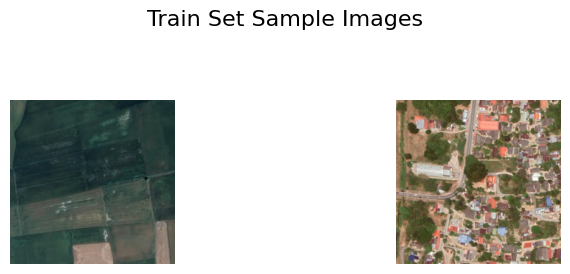

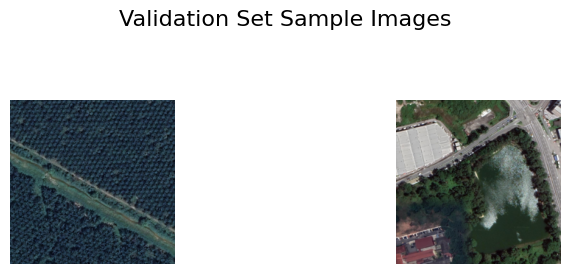

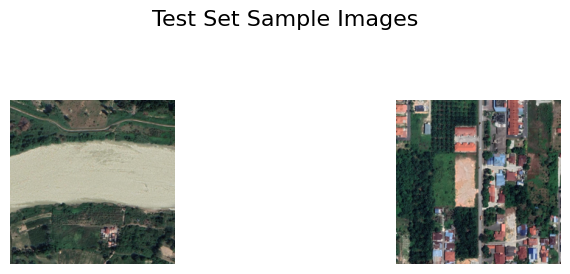

In [11]:
import matplotlib.pyplot as plt
import tensorflow as tf

# Get class names from one of the datasets
class_names = train_dataset.class_names

def collect_images(dataset, class_names, num_images=2):
    """Collect a few sample images per class."""
    class_images = {class_name: [] for class_name in class_names}

    for images, labels in dataset:
        for img, lbl in zip(images, labels):
            class_index = tf.argmax(lbl).numpy()  # because of 'categorical' label_mode
            class_name = class_names[class_index]
            if len(class_images[class_name]) < num_images:
                class_images[class_name].append(img.numpy().astype("uint8"))
        if all(len(imgs) == num_images for imgs in class_images.values()):
            break
    return class_images

def visualize_dataset(class_images, title="Sample Images"):
    """Visualize the collected images."""
    num_classes = len(class_images)
    plt.figure(figsize=(8, num_classes * 2.5))
    for i, (class_name, imgs) in enumerate(class_images.items()):
        for j, img in enumerate(imgs):
            ax = plt.subplot(num_classes, 2, i * 2 + j + 1)
            plt.imshow(img)
            if j == 0:
                ax.set_ylabel(class_name, fontsize=12)
            plt.axis("off")
    plt.suptitle(title, fontsize=16)
    plt.tight_layout(pad=2.0, rect=[0, 0.03, 1, 0.95])
    plt.show()

# Collect and visualize
train_images = collect_images(train_dataset, class_names, num_images=2)
val_images = collect_images(val_dataset, class_names, num_images=2)
test_images = collect_images(test_dataset, class_names, num_images=2)

visualize_dataset(train_images, title="Train Set Sample Images")
visualize_dataset(val_images, title="Validation Set Sample Images")
visualize_dataset(test_images, title="Test Set Sample Images")


# ResNet50 Model building

In [12]:
def identity_block(X, f, filters, training=True, initializer=random_uniform):
    """
    Implementation of the identity block as defined in Figure 4
    
    Arguments:
    X -- input tensor of shape (m, n_H_prev, n_W_prev, n_C_prev)
    f -- integer, specifying the shape of the middle CONV's window for the main path
    filters -- python list of integers, defining the number of filters in the CONV layers of the main path
    training -- True: Behave in training mode
                False: Behave in inference mode
    initializer -- to set up the initial weights of a layer. Equals to random uniform initializer
    
    Returns:
    X -- output of the identity block, tensor of shape (n_H, n_W, n_C)
    """
    
    # Retrieve Filters
    F1, F2, F3 = filters
    
    # Save the input value.
    X_shortcut = X
    cache = []
    # First component of main path
    X = Conv2D(filters = F1, kernel_size = 1, strides = (1, 1), padding = 'valid', kernel_initializer = initializer(seed=0))(X)
    X = BatchNormalization(axis = 3)(X, training = training) # Default axis
    X = Activation('relu')(X)
    
    # Second component of main path (≈3 lines)
    X = Conv2D(filters = F2, kernel_size = (f, f), strides = (1, 1), padding = 'same', kernel_initializer = initializer(seed=0))(X)
    X = BatchNormalization(axis = 3)(X, training = training)
    X = Activation('relu')(X)

    # Third component of main path (≈2 lines)
    X = Conv2D(filters = F3, kernel_size = (1, 1), strides = (1, 1), padding = 'valid', kernel_initializer = initializer(seed=0))(X)
    X = BatchNormalization(axis = 3)(X, training = training)

    # Final step: Add shortcut value to main path, and pass it through a RELU activation (≈2 lines)
    X = Add()([X_shortcut, X])
    X = X = Activation('relu')(X, training = training)

    return X

In [13]:
def convolutional_block(X, f, filters, s = 2, training=True, initializer=glorot_uniform):
    """
    Implementation of the convolutional block as defined in Figure 4
    
    Arguments:
    X -- input tensor of shape (m, n_H_prev, n_W_prev, n_C_prev)
    f -- integer, specifying the shape of the middle CONV's window for the main path
    filters -- python list of integers, defining the number of filters in the CONV layers of the main path
    s -- Integer, specifying the stride to be used
    training -- True: Behave in training mode
                False: Behave in inference mode
    initializer -- to set up the initial weights of a layer. Equals to Glorot uniform initializer, 
                   also called Xavier uniform initializer.
    
    Returns:
    X -- output of the convolutional block, tensor of shape (n_H, n_W, n_C)
    """
    
    # Retrieve Filters
    F1, F2, F3 = filters
    
    # Save the input value
    X_shortcut = X


    ##### MAIN PATH #####
    
    # First component of main path glorot_uniform(seed=0)
    X = Conv2D(filters = F1, kernel_size = 1, strides = (s, s), padding='valid', kernel_initializer = initializer(seed=0))(X)
    X = BatchNormalization(axis = 3)(X, training=training)
    X = Activation('relu')(X)

    
    # Second component of main path (≈3 lines)
    X = Conv2D(F2, (f, f), strides = (1, 1), padding = 'same', kernel_initializer = initializer(seed=0))(X)
    X = BatchNormalization(axis = 3)(X, training = training)
    X = Activation('relu')(X)

    # Third component of main path (≈2 lines)
    X = Conv2D(F3, (1, 1), strides = (1, 1), padding = 'valid', kernel_initializer = initializer(seed=0))(X)
    X = BatchNormalization(axis = 3)(X, training = training)

    ##### SHORTCUT PATH #### (≈2 lines)
    X_shortcut = Conv2D(F3, (1, 1), strides = (s, s), padding = 'valid', kernel_initializer = initializer(seed=0))(X_shortcut)
    X_shortcut = BatchNormalization(axis = 3)(X_shortcut, training = training)

    # Final step: Add shortcut value to main path (Use this order [X, X_shortcut]), and pass it through a RELU activation
    X = Add()([X, X_shortcut])
    X = Activation('relu')(X)
    
    return X

In [14]:
def ResNet50(input_shape = (224, 224, 3), classes = 1):
    """
    Stage-wise implementation of the architecture of the popular ResNet50:
    CONV2D -> BATCHNORM -> RELU -> MAXPOOL -> CONVBLOCK -> IDBLOCK*2 -> CONVBLOCK -> IDBLOCK*3
    -> CONVBLOCK -> IDBLOCK*5 -> CONVBLOCK -> IDBLOCK*2 -> AVGPOOL -> FLATTEN -> DENSE 

    Arguments:
    input_shape -- shape of the images of the dataset
    classes -- integer, number of classes

    Returns:
    model -- a Model() instance in Keras
    """
    
    # Define the input as a tensor with shape input_shape
    X_input = Input(input_shape)

    
    # Zero-Padding
    X = ZeroPadding2D((3, 3))(X_input)
    
    # Stage 1
    X = Conv2D(64, (7, 7), strides = (2, 2), kernel_initializer = glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis = 3)(X)
    X = Activation('relu')(X)
    X = MaxPooling2D((3, 3), strides=(2, 2))(X)

    # Stage 2
    X = convolutional_block(X, f = 3, filters = [64, 64, 256], s = 1)
    X = identity_block(X, 3, [64, 64, 256])
    X = identity_block(X, 3, [64, 64, 256])
    
   # Stage 3 (≈4 lines)
    X = convolutional_block(X, f = 3, filters = [128, 128, 512], s = 2)
    X = identity_block(X, 3, [128, 128, 512])
    X = identity_block(X, 3, [128, 128, 512])
    X = identity_block(X, 3, [128, 128, 512])

    # Stage 4 (≈6 lines)
    X = convolutional_block(X, f = 3, filters = [256, 256, 1024], s = 2)
    X = identity_block(X, 3, [256, 256, 1024])
    X = identity_block(X, 3, [256, 256, 1024])
    X = identity_block(X, 3, [256, 256, 1024])
    X = identity_block(X, 3, [256, 256, 1024])
    X = identity_block(X, 3, [256, 256, 1024])

    # Stage 5 (≈3 lines)
    X = convolutional_block(X, f = 3, filters = [512, 512, 2048], s = 2)
    X = identity_block(X, 3, [512, 512, 2048])
    X = identity_block(X, 3, [512, 512, 2048])

    # AVGPOOL (≈1 line). Use "X = AveragePooling2D(...)(X)"
    X = AveragePooling2D(pool_size = (2, 2), name = 'avg_pool')(X)
    

    # output layer
    X = Flatten()(X)
    X = Dense(1, activation='sigmoid', kernel_initializer = glorot_uniform(seed=0))(X)
    
    # Create model
    model = Model(inputs = X_input, outputs = X)

    return model

# Model train

In [15]:
#model = ResNet50(input_shape=(224,224,3), classes=1)

In [42]:
model = ResNet50()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [17]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Define a callback to save the best model based on validation loss (or validation accuracy)
checkpoint_cb = ModelCheckpoint(
    "best_resnet.keras",       # file to save the model
    monitor="val_accuracy",    # metric to monitor; can also use 'val_accuracy'
    save_best_only=True,   # only save when the monitored metric improves
    mode="max",            # 'min' because we want to minimize val_loss
    verbose=1
)

In [18]:
# Train the model with the callback
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    batch_size=16,
    callbacks=[checkpoint_cb]
)

Epoch 1/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7271 - loss: 2.3446
Epoch 1: val_accuracy improved from -inf to 0.47789, saving model to best_resnet.keras
202/202 ━━━━━━━━━━━━━━━━━━━━ 230s 1s/step - accuracy: 0.7272 - loss: 2.3410 - val_accuracy: 0.4779 - val_loss: 23.2732
Epoch 2/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7689 - loss: 0.7484
Epoch 2: val_accuracy improved from 0.47789 to 0.55635, saving model to best_resnet.keras
202/202 ━━━━━━━━━━━━━━━━━━━━ 213s 1s/step - accuracy: 0.7688 - loss: 0.7484 - val_accuracy: 0.5563 - val_loss: 9.4359
Epoch 3/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7781 - loss: 0.5759
Epoch 3: val_accuracy improved from 0.55635 to 0.62767, saving model to best_resnet.keras
202/202 ━━━━━━━━━━━━━━━━━━━━ 214s 1s/step - accuracy: 0.7781 - loss: 0.5757 - val_accuracy: 0.6277 - val_loss: 2.6822
Epoch 4/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8269 - loss: 0.4075
Epoch 4: val_accuracy improved fro

In [6]:
best_model = load_model("best_resnet.keras")

In [7]:
best_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d                │ (None, 230, 230, 3)       │               0 │ input_layer[0][0]          │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 112, 112, 64)      │           9,472 │ zero_padding2d[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 112, 112, 64)      │             256 │ conv2d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, 112, 112, 64)      │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 55, 55, 64)        │               0 │ activation[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 55, 55, 64)        │           4,160 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 55, 55, 64)        │             256 │ conv2d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_1 (Activation)     │ (None, 55, 55, 64)        │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 55, 55, 64)        │          36,928 │ activation_1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 55, 55, 64)        │             256 │ conv2d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_2 (Activation)     │ (None, 55, 55, 64)        │               0 │ batch_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 55, 55, 256)       │          16,640 │ activation_2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 55, 55, 256)       │          16,640 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 55, 55, 256)       │           1,024 │ conv2d_3[0][0]             │
│ (BatchNormalization)          │                           │               

 Total params: 70,712,197 (269.75 MB)

 Trainable params: 23,553,025 (89.85 MB)

 Non-trainable params: 53,120 (207.50 KB)

 Optimizer params: 47,106,052 (179.70 MB)

# analyzing results and visualization

In [32]:
# Trained model
test_loss, test_accuracy = best_model.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 237ms/step - accuracy: 0.8451 - loss: 0.8235
Test Loss: 0.8403
Test Accuracy: 0.8467


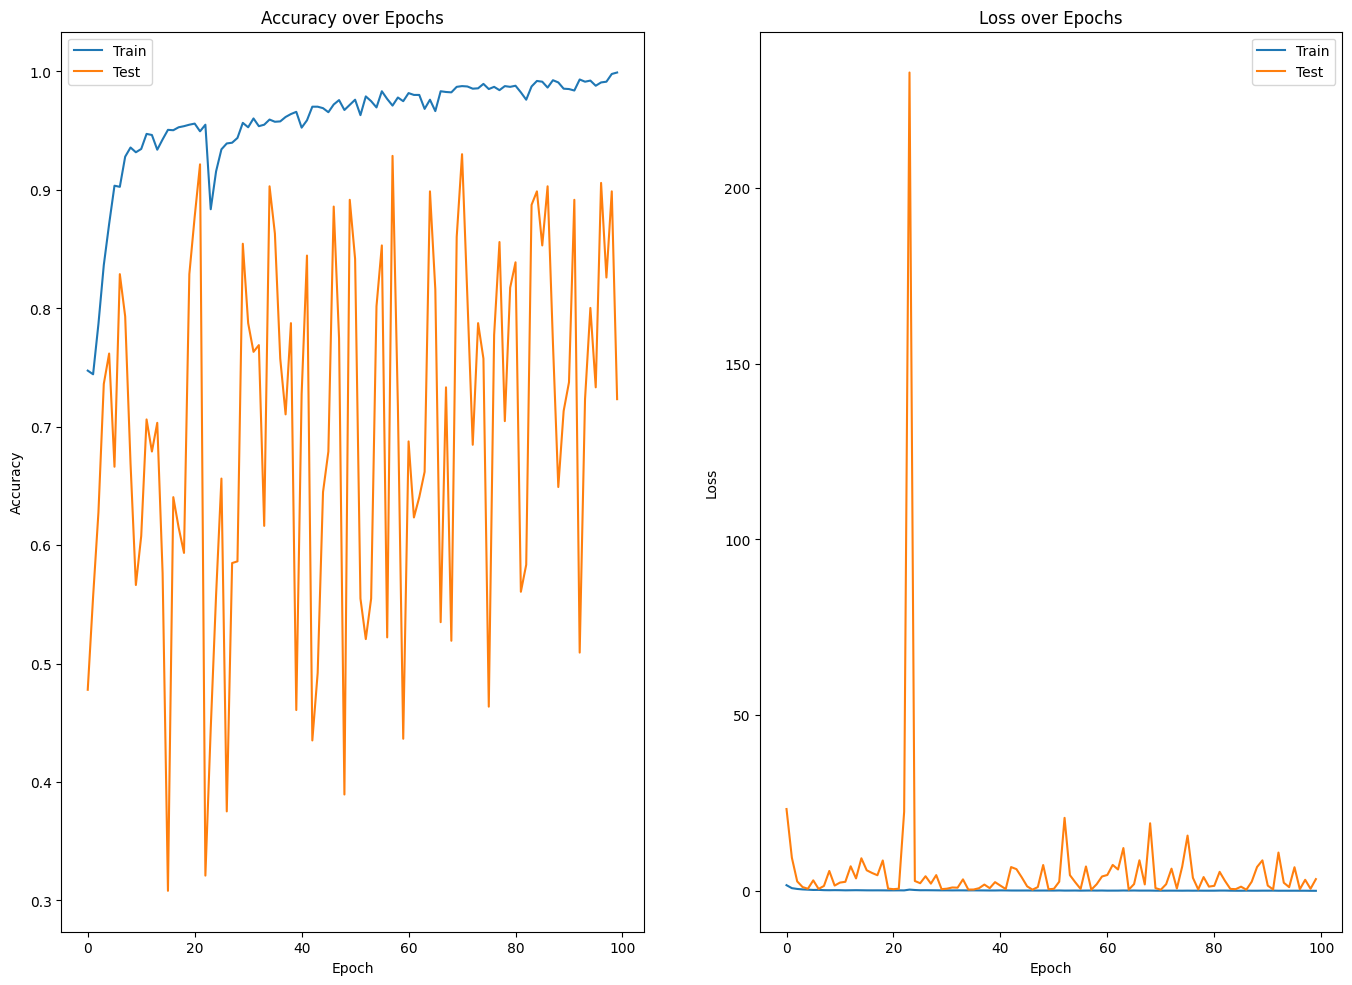

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16.53, 11.69))

# Plot accuracy
ax1.plot(history.history['accuracy'])
ax1.plot(history.history['val_accuracy'])
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy over Epochs')
ax1.legend(['Train', 'Test'], loc='upper left')

# Plot loss
ax2.plot(history.history['loss'])
ax2.plot(history.history['val_loss'])
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Loss over Epochs')
ax2.legend(['Train', 'Test'], loc='upper right')

plt.show()


In [9]:
test_dataset2 = tf.keras.preprocessing.image_dataset_from_directory(
    r"C:\Users\YapJack\Desktop\DeepEarthMY\test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle = False
)

Found 711 files belonging to 2 classes.


In [11]:
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load the trained model
model = load_model("best_resnet.keras")

# Predict the results on the test dataset
predictions = model.predict(test_dataset2)

# Convert predictions to class labels (flatten to 1D)
predictions = (predictions > 0.5).astype(int).flatten()

# Get the true labels from the test dataset (flatten each batch)
true_labels = np.concatenate([y.numpy().flatten() for x, y in test_dataset2], axis=0)

print(f"Predictions shape: {predictions.shape}")
print(f"True labels shape: {true_labels.shape}")

# Calculate metrics
accuracy = accuracy_score(true_labels, predictions)
precision = precision_score(true_labels, predictions)
recall = recall_score(true_labels, predictions)
f1 = f1_score(true_labels, predictions)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 234ms/step
Predictions shape: (711,)
True labels shape: (711,)
Accuracy: 0.8467
Precision: 0.7463
Recall: 0.9806
F1 Score: 0.8476


# Confusion matrix

In [36]:
import numpy as np
from sklearn.metrics import accuracy_score

# Predict and flatten
pred_probs = best_model.predict(test_dataset)
pred_labels = (pred_probs > 0.5).astype("int32").flatten()

# Get true labels (flattened)
true_labels = np.concatenate([y.numpy() for x, y in test_dataset], axis=0).astype("int32")

# Compute accuracy manually
acc_manual = accuracy_score(true_labels, pred_labels)
print(f"Manual Accuracy: {acc_manual:.4f}")


45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 235ms/step
Manual Accuracy: 0.5120
